In [59]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings('ignore')


sns.set_theme()
sns.set_palette('Set2')
sns.set_style("whitegrid")
sns.set_context("talk")

In [60]:
data = pd.read_csv('hotel_bookings.csv')

data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [61]:
data.shape

(119390, 32)

In [62]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [63]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [64]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [65]:
data.drop_duplicates(inplace = True)
data = data.reset_index()


In [66]:
data.drop(columns=['agent', 'company'], inplace=True)
data.dropna(subset=['children'], inplace=True)
data['country'] = data['country'].fillna("other")

In [67]:
data.isna().sum()

index                             0
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [68]:
data.info()

<class 'pandas.DataFrame'>
Index: 87392 entries, 0 to 87395
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   index                           87392 non-null  int64  
 1   hotel                           87392 non-null  str    
 2   is_canceled                     87392 non-null  int64  
 3   lead_time                       87392 non-null  int64  
 4   arrival_date_year               87392 non-null  int64  
 5   arrival_date_month              87392 non-null  str    
 6   arrival_date_week_number        87392 non-null  int64  
 7   arrival_date_day_of_month       87392 non-null  int64  
 8   stays_in_weekend_nights         87392 non-null  int64  
 9   stays_in_week_nights            87392 non-null  int64  
 10  adults                          87392 non-null  int64  
 11  children                        87392 non-null  float64
 12  babies                          87392 non-null  

In [69]:
data.columns

Index(['index', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [70]:
cat_cols = ['hotel', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel', 'reserved_room_type',
       'assigned_room_type','deposit_type','customer_type', 
       'reservation_status']

In [71]:
for col in cat_cols:
    print("-------------------")
    print(data[col].value_counts())

-------------------
hotel
City Hotel      53424
Resort Hotel    33968
Name: count, dtype: int64
-------------------
adults
2     64494
1     16503
3      5934
0       385
4        60
26        5
27        2
20        2
5         2
40        1
50        1
55        1
6         1
10        1
Name: count, dtype: int64
-------------------
children
0.0     79028
1.0      4695
2.0      3593
3.0        75
10.0        1
Name: count, dtype: int64
-------------------
babies
0     86478
1       897
2        15
10        1
9         1
Name: count, dtype: int64
-------------------
meal
BB           67974
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64
-------------------
country
PRT    27449
GBR    10433
FRA     8837
ESP     7252
DEU     5387
       ...  
NCL        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64
-------------------
market_segment
Online TA        51617
Offline TA/TO    13889
Direct  

In [72]:
# Hotel can't be booked without atleast one adult and also removing extreme outliers
data = data[(data['adults'] > 0) & (data['adults'] <= 4)]

# Making children column as int
data['children'] = data['children'].astype(int)

#Removing outliers of babies columns
data = data[data['babies'] <= 2]

In [73]:
data.drop(columns=['index'], inplace = True)

In [74]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,0,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06
87392,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,0,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07
87393,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,0,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07
87394,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,0,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [75]:
# Droping rows with adr 0.00 coz not any hotel is free 

data = data[data['adr'] > 0]

In [76]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,C,0,No Deposit,0,Transient,107.00,0,0,Check-Out,2015-07-03
6,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,C,0,No Deposit,0,Transient,103.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,0,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06
87392,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,0,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07
87393,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,0,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07
87394,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,0,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [77]:
data['reservation_status_date'] = pd.to_datetime(data['reservation_status_date'])

data['reservation_year'] = data['reservation_status_date'].dt.year
data['reservation_month'] = data['reservation_status_date'].dt.month
data['reservation_day'] = data['reservation_status_date'].dt.day


data.drop(columns=['reservation_status_date'], inplace=True)

In [78]:
data['reservation_month'] = data['reservation_month'].map({
    1:"January",
    2:"Feburary",
    3:"March",
    4:"April",
    5:"May",
    6:"June",
    7:"July",
    8:"August",
    9:"September",
    10:"October",
    11:"November",
    12:"December"
    
})

In [79]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_year,reservation_month,reservation_day
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,Check-Out,2015,July,2
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,Check-Out,2015,July,2
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.00,0,1,Check-Out,2015,July,3
5,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,107.00,0,0,Check-Out,2015,July,3
6,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,103.00,0,1,Check-Out,2015,July,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,0,Transient,96.14,0,0,Check-Out,2017,September,6
87392,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,0,Transient,225.43,0,2,Check-Out,2017,September,7
87393,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,157.71,0,4,Check-Out,2017,September,7
87394,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,104.40,0,0,Check-Out,2017,September,7


In [80]:
data.info()

<class 'pandas.DataFrame'>
Index: 85367 entries, 2 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           85367 non-null  str    
 1   is_canceled                     85367 non-null  int64  
 2   lead_time                       85367 non-null  int64  
 3   arrival_date_year               85367 non-null  int64  
 4   arrival_date_month              85367 non-null  str    
 5   arrival_date_week_number        85367 non-null  int64  
 6   arrival_date_day_of_month       85367 non-null  int64  
 7   stays_in_weekend_nights         85367 non-null  int64  
 8   stays_in_week_nights            85367 non-null  int64  
 9   adults                          85367 non-null  int64  
 10  children                        85367 non-null  int64  
 11  babies                          85367 non-null  int64  
 12  meal                            85367 non-null  

In [81]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_year,reservation_day
count,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000,85367.000000
mean,0.278293,80.610236,2016.215669,26.799032,15.822273,1.017103,2.652910,1.886080,0.135357,0.010531,0.034205,0.029016,0.169140,0.265044,0.743601,108.631601,0.084951,0.699193,2016.191889,15.771247
std,0.448161,85.881612,0.684645,13.633696,8.836961,1.026515,2.032673,0.493392,0.448623,0.103787,0.181757,0.365261,1.677669,0.702204,10.013467,53.396599,0.282691,0.830620,0.678969,8.792717
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.260000,0.000000,0.000000,2014.000000,1.000000
25%,0.000000,12.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.500000,0.000000,0.000000,2016.000000,8.000000
50%,0.000000,50.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.000000,0.000000,0.000000,2016.000000,16.000000
75%,1.000000,126.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,1.000000,2017.000000,23.000000
max,1.000000,709.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,4.000000,10.000000,2.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000,2017.000000,31.000000


<Axes: xlabel='lead_time', ylabel='Count'>

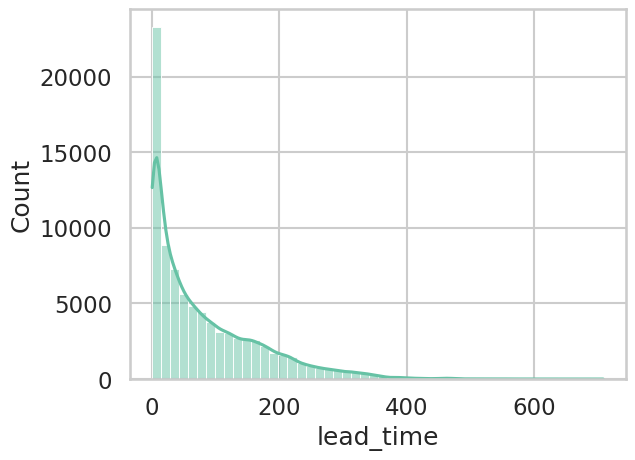

In [82]:
plt.Figure(figsize=(12,6))
sns.histplot(data['lead_time'], kde=True, bins=50)

In [83]:
data[data['lead_time'] > 300].count()

hotel                             2225
is_canceled                       2225
lead_time                         2225
arrival_date_year                 2225
arrival_date_month                2225
arrival_date_week_number          2225
arrival_date_day_of_month         2225
stays_in_weekend_nights           2225
stays_in_week_nights              2225
adults                            2225
children                          2225
babies                            2225
meal                              2225
country                           2225
market_segment                    2225
distribution_channel              2225
is_repeated_guest                 2225
previous_cancellations            2225
previous_bookings_not_canceled    2225
reserved_room_type                2225
assigned_room_type                2225
booking_changes                   2225
deposit_type                      2225
days_in_waiting_list              2225
customer_type                     2225
adr                      

In [84]:
data = data[data['lead_time'] <= 300]

## Data is almost cleaned let's visulaize some things

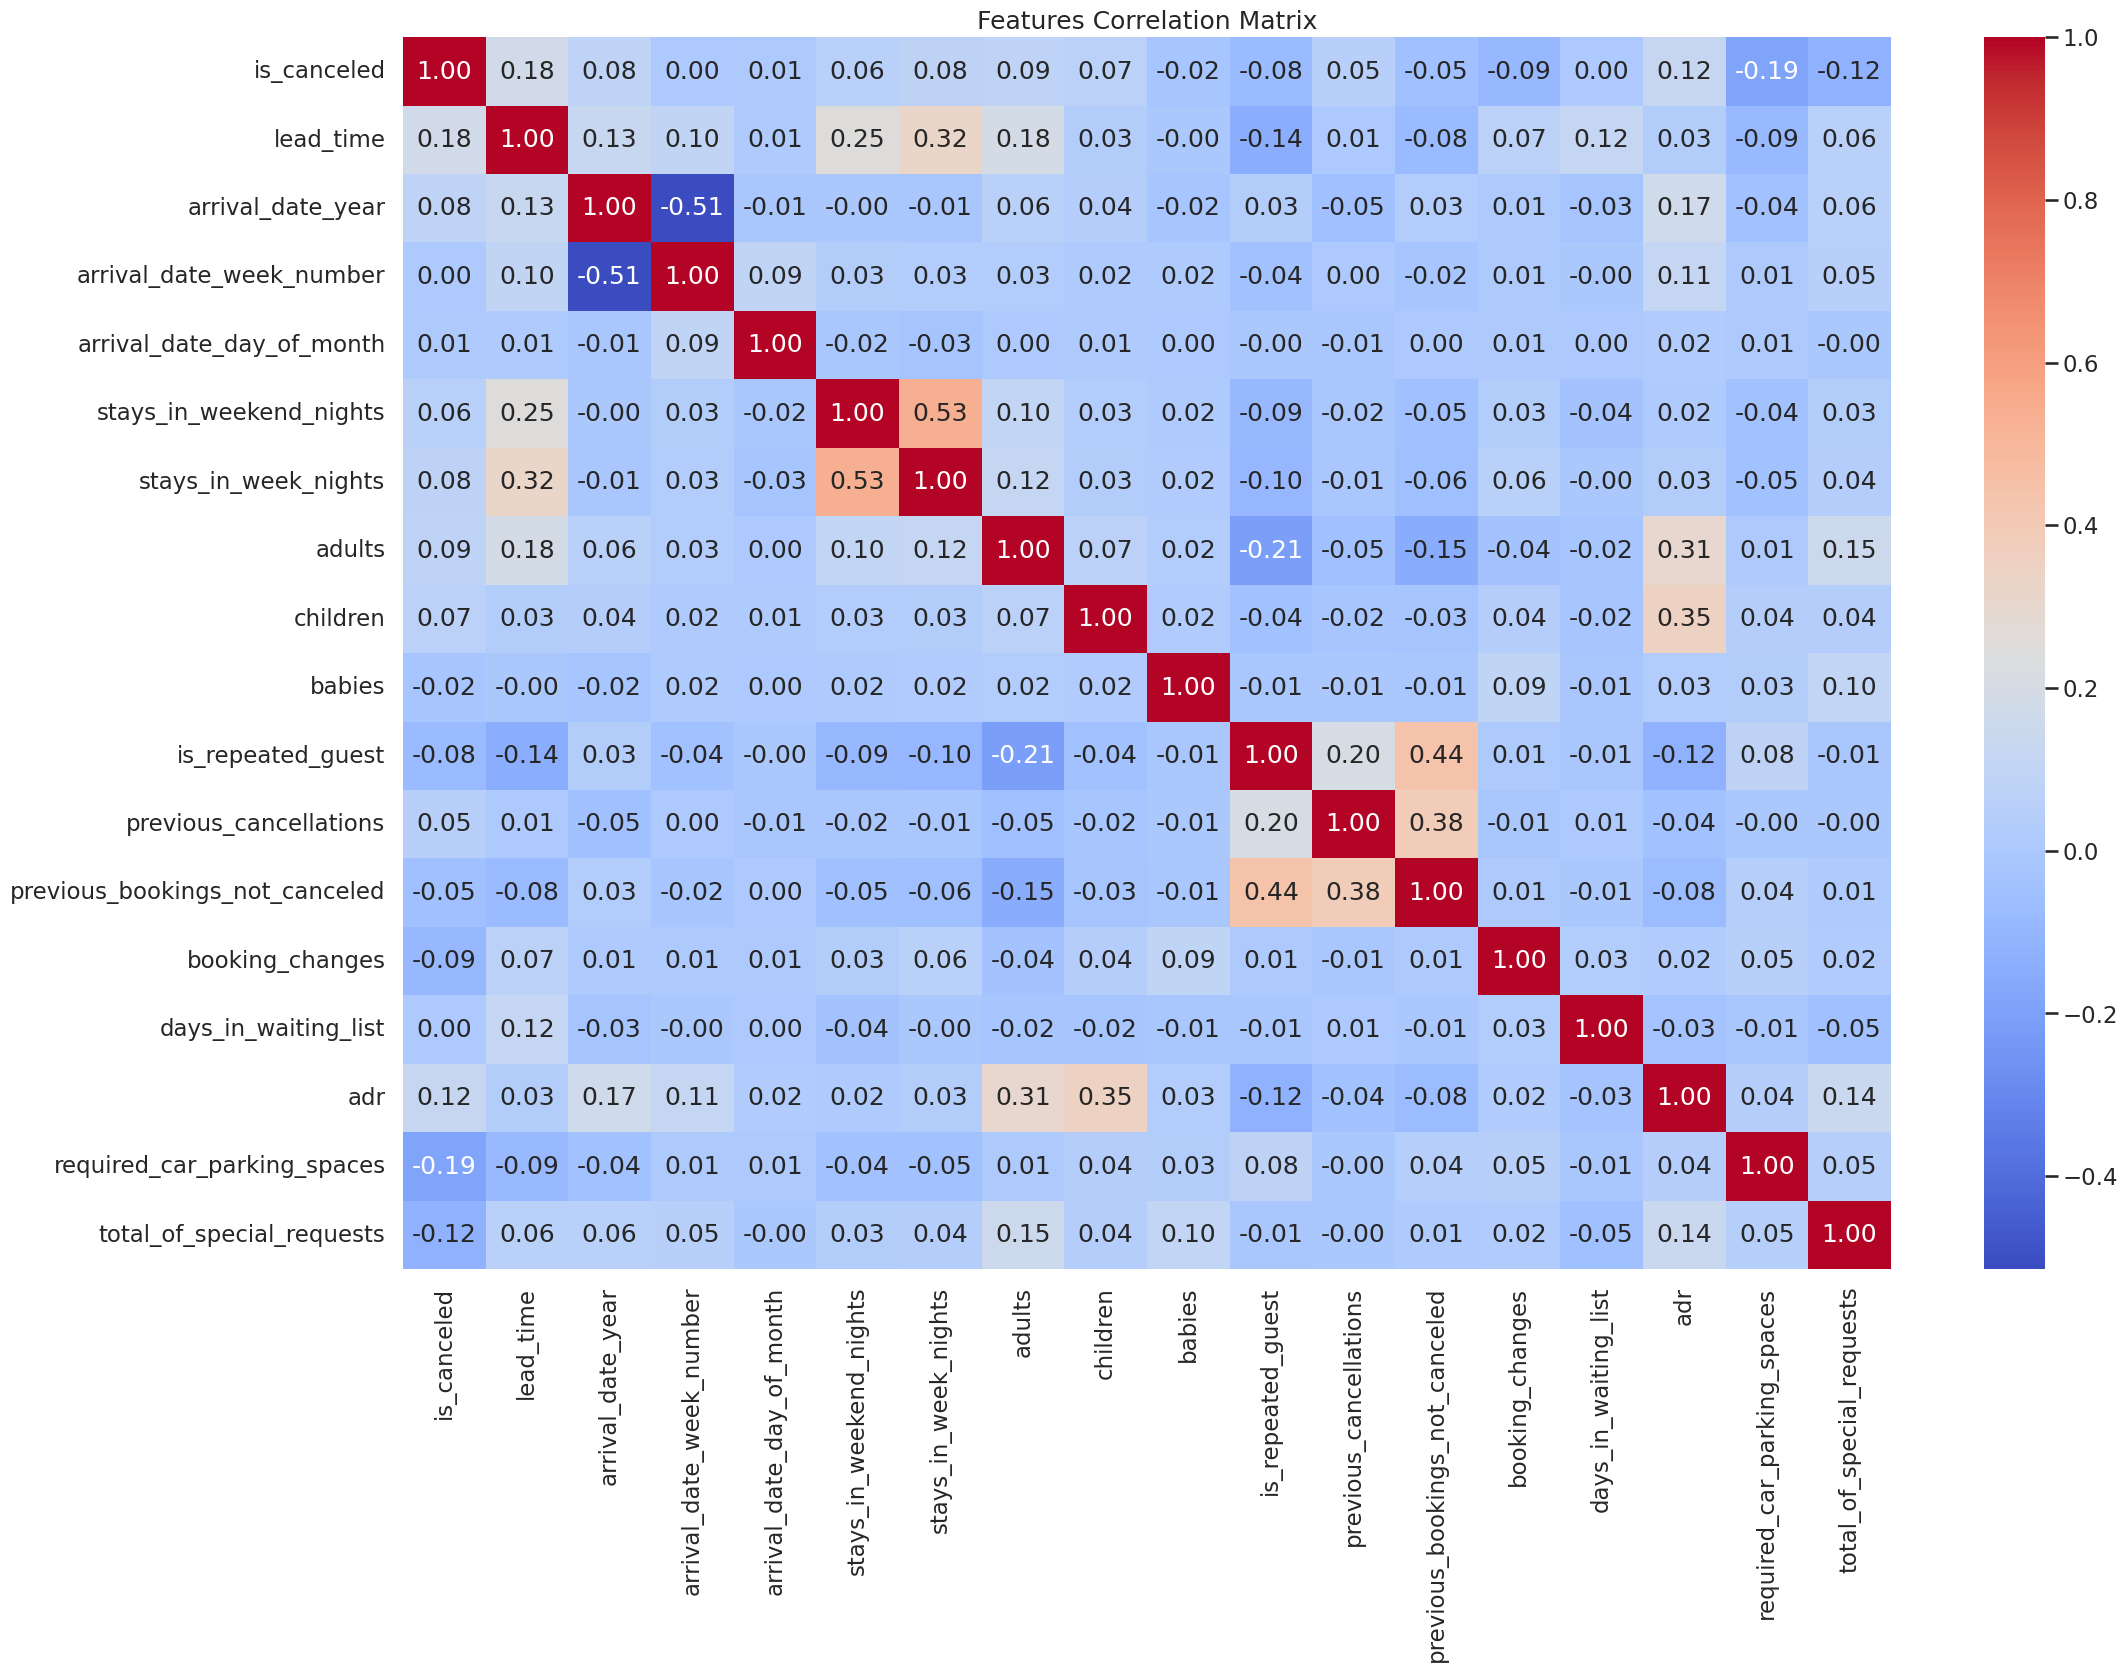

In [85]:
plt.figure(figsize=(24, 16))

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(data[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Features Correlation Matrix")
plt.show()

## Heatmap not showing any strong relationship of targeted columns with other but their is mutual relationships b/w features

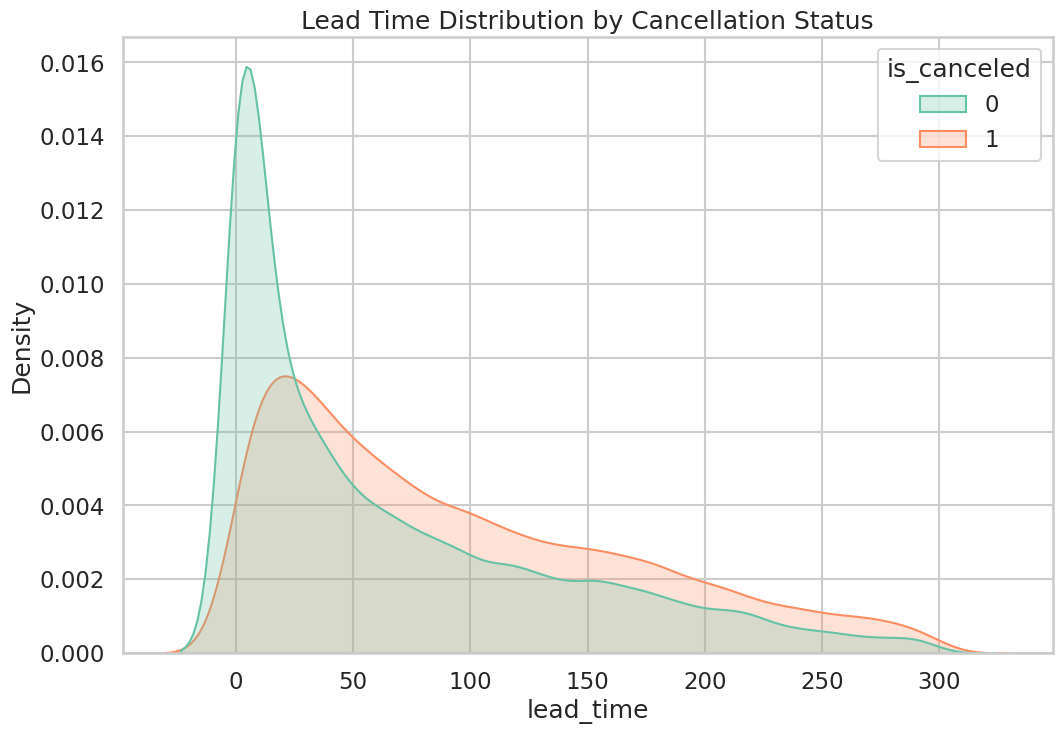

In [86]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=data, x='lead_time', hue='is_canceled', fill=True, common_norm=False)
plt.title("Lead Time Distribution by Cancellation Status")
plt.show()

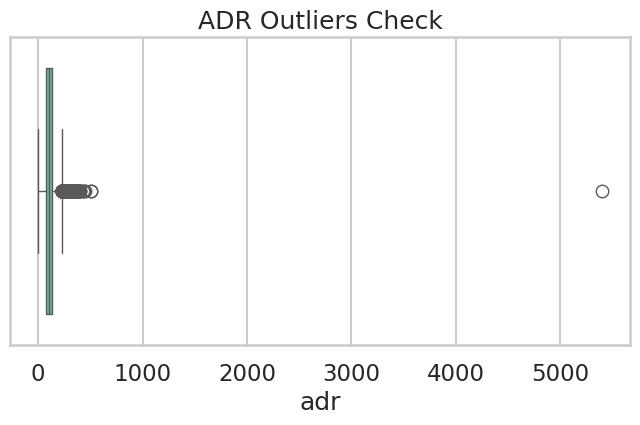

In [87]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['adr'])
plt.title("ADR Outliers Check")
plt.show()

In [88]:
data[data['adr'] > 250]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_year,reservation_month,reservation_day
756,Resort Hotel,0,3,2015,July,31,30,0,3,3,...,No Deposit,0,Transient,250.33,0,2,Check-Out,2015,August,2
760,Resort Hotel,0,52,2015,July,31,30,0,3,2,...,No Deposit,0,Transient,280.74,1,0,Check-Out,2015,July,30
799,Resort Hotel,1,10,2015,August,31,1,0,1,2,...,No Deposit,0,Transient-Party,252.00,0,0,Canceled,2015,July,29
874,Resort Hotel,0,9,2015,August,32,6,0,3,2,...,No Deposit,0,Transient,268.00,1,1,Check-Out,2015,August,9
885,Resort Hotel,1,49,2015,August,32,7,0,2,2,...,No Deposit,0,Transient,267.00,0,0,Canceled,2015,June,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87202,City Hotel,0,130,2017,August,34,23,2,5,2,...,No Deposit,0,Transient,300.00,0,1,Check-Out,2017,August,30
87214,City Hotel,0,52,2017,August,35,27,2,1,3,...,No Deposit,0,Transient,258.00,1,2,Check-Out,2017,August,30
87218,City Hotel,0,5,2017,August,35,29,0,1,2,...,No Deposit,0,Transient,259.00,0,0,Check-Out,2017,August,30
87225,City Hotel,0,0,2017,August,35,29,0,1,2,...,No Deposit,0,Transient,270.00,0,0,Check-Out,2017,August,30


In [89]:
# Removing extreme outliers
data = data[data['adr'] <= 250]

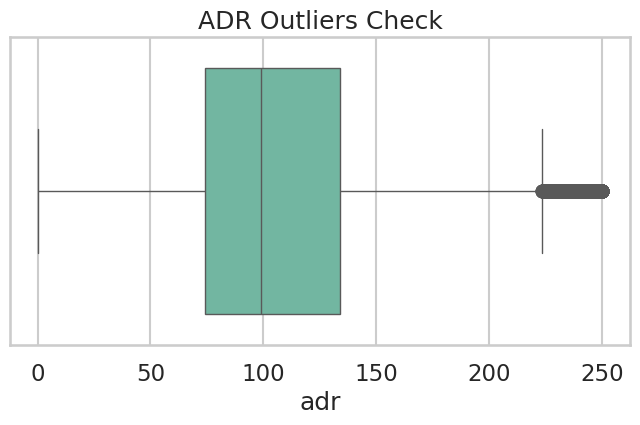

In [90]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['adr'])
plt.title("ADR Outliers Check")
plt.show()

## Now it's look good

In [91]:
# One more thing that data describe shows that there are bookings with 0 baby, 0 children, 0 adults 
# Fixing it as it make total person 0

data = data[(data['adults'] + data['children'] + data['babies']) > 0]

In [92]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_year,reservation_month,reservation_day
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,Check-Out,2015,July,2
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,Check-Out,2015,July,2
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.00,0,1,Check-Out,2015,July,3
5,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,107.00,0,0,Check-Out,2015,July,3
6,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,103.00,0,1,Check-Out,2015,July,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,0,Transient,96.14,0,0,Check-Out,2017,September,6
87392,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,0,Transient,225.43,0,2,Check-Out,2017,September,7
87393,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,157.71,0,4,Check-Out,2017,September,7
87394,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,104.40,0,0,Check-Out,2017,September,7


In [93]:
# Let's have some feature engineering it will help later

data['total_guests'] = data['adults'] + data['children'] + data['babies']

data['total_guests'] = data['total_guests'].astype(int)

data = data.reset_index().drop(columns=['index'])

In [94]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_year,reservation_month,reservation_day,total_guests
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.00,0,0,Check-Out,2015,July,2,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.00,0,0,Check-Out,2015,July,2,1
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.00,0,1,Check-Out,2015,July,3,2
3,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,0,Transient,107.00,0,0,Check-Out,2015,July,3,2
4,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,0,Transient,103.00,0,1,Check-Out,2015,July,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81938,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,Transient,96.14,0,0,Check-Out,2017,September,6,2
81939,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,Transient,225.43,0,2,Check-Out,2017,September,7,3
81940,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,Transient,157.71,0,4,Check-Out,2017,September,7,2
81941,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,Transient,104.40,0,0,Check-Out,2017,September,7,2


In [95]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_year,reservation_day,total_guests
count,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,...,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000,81943.000000
mean,0.272031,73.408406,2016.202922,26.643643,15.816177,1.005748,2.617490,1.881039,0.123427,0.010349,...,0.028825,0.174768,0.257398,0.605970,106.356837,0.084400,0.698046,2016.184104,15.763836,2.014815
std,0.445008,73.897276,0.685059,13.767394,8.842534,1.017699,2.009632,0.492981,0.426160,0.102876,...,0.370857,1.707863,0.686226,8.270967,45.945755,0.281912,0.826507,0.678586,8.794956,0.681596
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.260000,0.000000,0.000000,2014.000000,1.000000,1.000000
25%,0.000000,11.000000,2016.000000,15.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,74.250000,0.000000,0.000000,2016.000000,8.000000,2.000000
50%,0.000000,48.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,99.000000,0.000000,0.000000,2016.000000,16.000000,2.000000
75%,1.000000,118.000000,2017.000000,37.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,133.980000,0.000000,1.000000,2017.000000,23.000000,2.000000
max,1.000000,300.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,4.000000,10.000000,2.000000,...,26.000000,72.000000,17.000000,259.000000,250.000000,8.000000,5.000000,2017.000000,31.000000,12.000000


In [96]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 81943 entries, 0 to 81942
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           81943 non-null  str    
 1   is_canceled                     81943 non-null  int64  
 2   lead_time                       81943 non-null  int64  
 3   arrival_date_year               81943 non-null  int64  
 4   arrival_date_month              81943 non-null  str    
 5   arrival_date_week_number        81943 non-null  int64  
 6   arrival_date_day_of_month       81943 non-null  int64  
 7   stays_in_weekend_nights         81943 non-null  int64  
 8   stays_in_week_nights            81943 non-null  int64  
 9   adults                          81943 non-null  int64  
 10  children                        81943 non-null  int64  
 11  babies                          81943 non-null  int64  
 12  meal                            81943 non-n

# Preprocessing

In [97]:
data_cleaned = data.copy()

## Selected top 10 countries after anova test 

In [98]:
top_10_countries = ['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'BRA', 'NLD']


data_cleaned['country'] = data_cleaned['country'].apply(lambda x: x if x in top_10_countries else 'other')

country_map = {
    'PRT': 'Portugal',
    'GBR': 'United Kingdom',
    'FRA': 'France',
    'ESP': 'Spain',
    'DEU': 'Germany',
    'ITA': 'Italy',
    'IRL': 'Ireland',
    'BEL': 'Belgium',
    'BRA': 'Brazil',
    'NLD': 'Netherlands',  
    'other': 'others'
}

data_cleaned['country'] = data_cleaned['country'].map(country_map)

In [99]:
data_cleaned['country'].value_counts()

country
Portugal          24825
others            15263
United Kingdom     9622
France             8603
Spain              6862
Germany            5153
Italy              2981
Ireland            2867
Belgium            1999
Brazil             1911
Netherlands        1857
Name: count, dtype: int64

## Dropping wasted columns

In [100]:
# Dropping 'reservation_status' to prevent data leakage

drop_list = ['reservation_status',
    'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month',
    'reservation_year', 'reservation_month', 'reservation_day'
]

In [101]:
data_cleaned.drop(columns = drop_list, inplace = True)

## Feature engineering and reducing the risk of dimensions

In [102]:
data_cleaned['room_type_changed'] = (data_cleaned['reserved_room_type'] != data_cleaned['assigned_room_type']).astype(int)

In [103]:
data_cleaned.drop(columns = ['reserved_room_type','assigned_room_type'], inplace = True)

In [104]:
data_cleaned['meal'].value_counts()

meal
BB           64075
SC            9160
HB            7971
Undefined      435
FB             302
Name: count, dtype: int64

In [105]:
data_cleaned

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,previous_bookings_not_canceled,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,room_type_changed
0,Resort Hotel,0,7,27,0,1,1,0,0,BB,...,0,0,No Deposit,0,Transient,75.00,0,0,1,1
1,Resort Hotel,0,13,27,0,1,1,0,0,BB,...,0,0,No Deposit,0,Transient,75.00,0,0,1,0
2,Resort Hotel,0,14,27,0,2,2,0,0,BB,...,0,0,No Deposit,0,Transient,98.00,0,1,2,0
3,Resort Hotel,0,0,27,0,2,2,0,0,BB,...,0,0,No Deposit,0,Transient,107.00,0,0,2,0
4,Resort Hotel,0,9,27,0,2,2,0,0,FB,...,0,0,No Deposit,0,Transient,103.00,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81938,City Hotel,0,23,35,2,5,2,0,0,BB,...,0,0,No Deposit,0,Transient,96.14,0,0,2,0
81939,City Hotel,0,102,35,2,5,3,0,0,BB,...,0,0,No Deposit,0,Transient,225.43,0,2,3,0
81940,City Hotel,0,34,35,2,5,2,0,0,BB,...,0,0,No Deposit,0,Transient,157.71,0,4,2,0
81941,City Hotel,0,109,35,2,5,2,0,0,BB,...,0,0,No Deposit,0,Transient,104.40,0,0,2,0


In [106]:
## Removing features that are not important and also independent features

data_cleaned.drop(columns = ['arrival_date_week_number','days_in_waiting_list'], inplace = True)

In [107]:
data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 81943 entries, 0 to 81942
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           81943 non-null  str    
 1   is_canceled                     81943 non-null  int64  
 2   lead_time                       81943 non-null  int64  
 3   stays_in_weekend_nights         81943 non-null  int64  
 4   stays_in_week_nights            81943 non-null  int64  
 5   adults                          81943 non-null  int64  
 6   children                        81943 non-null  int64  
 7   babies                          81943 non-null  int64  
 8   meal                            81943 non-null  str    
 9   country                         81943 non-null  str    
 10  market_segment                  81943 non-null  str    
 11  distribution_channel            81943 non-null  str    
 12  is_repeated_guest               81943 non-n

In [108]:
data_test = data_cleaned.copy()

In [109]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = data_test.select_dtypes(include=['str']).columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(data_test[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=data_test.index)

data_test = data_test.drop(columns=cat_cols)
data_test = pd.concat([data_test, encoded_df], axis=1)

# Feature Selections

## Anova test 

In [110]:
from sklearn.feature_selection import f_classif



f_scores, p_values = f_classif(data_test.drop(columns = ['is_canceled']), y = data_test['is_canceled'])

anova_results = pd.DataFrame({
    'Feature': data_test.drop(columns = ['is_canceled']).columns,
    'F_Score': f_scores,
    'P_Value': p_values
})


anova_results['Hypothesis_Status'] = anova_results['P_Value'].apply(
    lambda x: 'Important (Reject H0)' if x < 0.05 else 'Not Important (Accept H0)'
)

anova_results = anova_results.sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("=== ANOVA F-TEST RESULTS ===")
print(anova_results.to_string())

=== ANOVA F-TEST RESULTS ===
                           Feature      F_Score        P_Value          Hypothesis_Status
0         market_segment_Online TA  3911.214519   0.000000e+00      Important (Reject H0)
1                room_type_changed  3743.947260   0.000000e+00      Important (Reject H0)
2      required_car_parking_spaces  2839.656325   0.000000e+00      Important (Reject H0)
3                        lead_time  2684.550026   0.000000e+00      Important (Reject H0)
4       distribution_channel_TA/TO  1807.569811   0.000000e+00      Important (Reject H0)
5          deposit_type_Non Refund  1730.375223   0.000000e+00      Important (Reject H0)
6          deposit_type_No Deposit  1514.402435   0.000000e+00      Important (Reject H0)
7                              adr  1412.600118  1.592636e-306      Important (Reject H0)
8     market_segment_Offline TA/TO  1316.716701  4.975728e-286      Important (Reject H0)
9                 country_Portugal  1314.840087  1.253783e-285      Imp

# Data leakage in reversation_status columns 

## Removing dates columns as they are not important 

## Also choosing just top 10 countries in above OneHotEncoding

In [111]:
data_test.columns

Index(['is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'room_type_changed', 'hotel_City Hotel',
       'hotel_Resort Hotel', 'meal_BB', 'meal_FB', 'meal_HB', 'meal_SC',
       'meal_Undefined', 'country_Belgium', 'country_Brazil', 'country_France',
       'country_Germany', 'country_Ireland', 'country_Italy',
       'country_Netherlands', 'country_Portugal', 'country_Spain',
       'country_United Kingdom', 'country_others', 'market_segment_Aviation',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Direct', 'market_segment_Groups',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'distribution_channel_Corporate', 'distribution_channel_Direct',


## Finalized the data

data_cleaned is the final selected data without encoding and feature importance test performed on data_test

## making Pipeline

In [112]:
X = data_cleaned.drop(columns = ['is_canceled'])
y = data_cleaned['is_canceled']

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['str']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features,
        ),
    ]
)


# Splitting data into train and test data

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = RandomForestClassifier()

pipeline = Pipeline([('preprocessor', preprocessor), 
                     ('model', model)])

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__criterion":["gini","entropy",'log_loss'],
    "model__n_estimators":[100, 300,500,700,900],
    "model__max_features":['sqrt','log2'],
    "model__class_weight":['balanced','balanced_subsample']
    
}
searcher = GridSearchCV(param_grid=param_grid,
                        estimator=pipeline,
                        cv=5,
                        scoring="accuracy",
                        n_jobs=-1,
                        verbose=2,
                        )


searcher.fit(X_train,y_train)

In [ ]:
results_df = pd.DataFrame(searcher.cv_results_)


results_df = results_df[["mean_test_score", "params"]].sort_values(
    by="mean_test_score", ascending=False
)

results_df

In [ ]:
print(f"Best Parameters: {searcher.best_params_}")
print(f"Best Training Score: {searcher.best_score_:.4f}")